Loaded the dataset


In [1]:
import pandas as pd
df=pd.read_csv("/content/Sentiment_dataset.csv")
df.head()

,news_title,reddit_title,sentiment,text,url
0,Mark Cuban launches generic drug company,Billionaire Mark Cuban just launched a drug co...,1.0,Billionaire investor and Shark Tank star Mark ...,https://www.beckershospitalreview.com/pharmacy...
1,From Defendant to Defender: One Wrongfully Con...,"Man falsely imprisoned for 10 years, uses pris...",1.0,Attorney Jarrett Adams recently helped overtur...,https://www.nbcnews.com/news/us-news/defendant...
2,"Amazon Tribe Wins Lawsuit Against Big Oil, Sav...",Amazon tribe wins legal battle against oil com...,1.0,The Amazon Rainforest is well known across the...,https://www.disclose.tv/amazon-tribe-wins-laws...
3,Newark police: No officer fired a single shot ...,Newark police: No officer fired a single shot ...,1.0,Newark police: No officer fired a single shot ...,https://newjersey.news12.com/newark-police-no-...
4,Ingen barn døde i trafikken i 2019,No children died in traffic accidents in Norwa...,1.0,I 1970 døde det 560 mennesker i den norske tra...,https://www.nrk.no/trondelag/ingen-barn-dode-i...


In [2]:
import matplotlib.pyplot as plt
from textblob import TextBlob

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 848 entries, 0 to 847
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   news_title    848 non-null    object 
 1   reddit_title  848 non-null    object 
 2   sentiment     848 non-null    float64
 3   text          848 non-null    object 
 4   url           848 non-null    object 
dtypes: float64(1), object(4)
memory usage: 33.3+ KB


In [4]:
df.describe()

,sentiment
count,848.000000
mean,0.882075
std,0.322709
min,0.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,1.000000


Finding the missing values

In [10]:
df.isnull().sum()

,0
news_title,0
reddit_title,0
sentiment,0
text,0
url,0
sentiment_score,0


In [12]:
df.shape

(848, 6)

In [14]:
df['sentiment'].value_counts()

,count
sentiment,
neutral,418
positive,296
negative,134


In [5]:
df['news_title']=df['news_title'].str.lower()

Usedd TextBlob to calculate sentiment

In [7]:
def get_sentiment(text):
  analysis=TextBlob(text)
  return analysis.sentiment.polarity
df['sentiment_score']=df['news_title'].apply(get_sentiment)

In [8]:
def classify(score):
  if score >0:
    return "positive"
  elif score <0:
    return "negative"
  else:
    return "neutral"
df['sentiment']=df['sentiment_score'].apply(classify)

Visualize the sentiment distribution

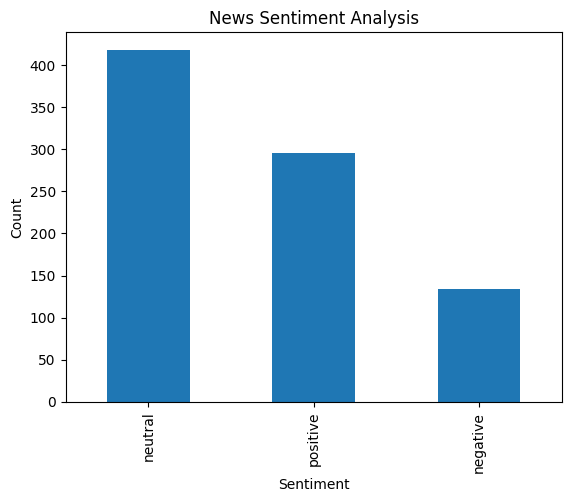

In [15]:
df['sentiment'].value_counts().plot(kind='bar')
plt.title("News Sentiment Analysis")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

Required libraries

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report

Target is sentiment

In [17]:
x=df['news_title']
y=df['sentiment']

Convert text to numerical features

In [18]:
vectorizer=TfidfVectorizer()
X_vectorized=vectorizer.fit_transform(x)

In [19]:
X_train,X_test,y_train,y_test=train_test_split(X_vectorized,y,test_size=0.2,random_state=42)

Train the model

In [20]:
model=LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

Test the model

In [21]:
y_pred=model.predict(X_test)

In [22]:
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

Accuracy: 0.5588235294117647


In [24]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        28
     neutral       0.51      0.96      0.66        77
    positive       0.88      0.32      0.47        65

    accuracy                           0.56       170
   macro avg       0.46      0.43      0.38       170
weighted avg       0.56      0.56      0.48       170



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Visualize model accuracy

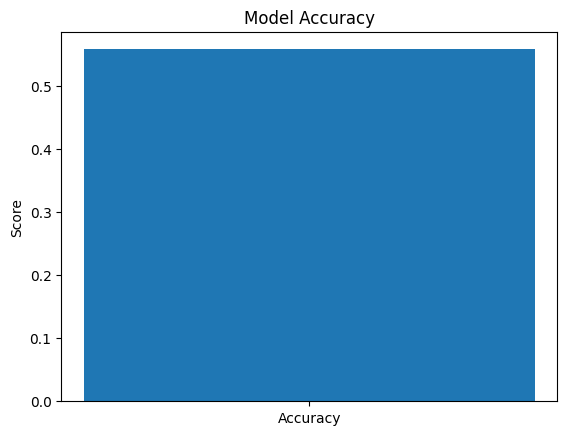

In [25]:
accuracy_value=accuracy_score(y_test,y_pred)
plt.bar(['Accuracy'],[accuracy_value])
plt.title("Model Accuracy")
plt.ylabel("Score")
plt.show()

Visualization of confusion Matrix

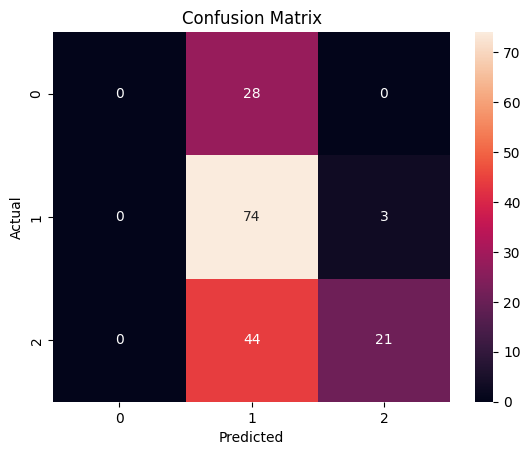

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Testing the model by predicting the sentiment for new news headline

In [28]:
new_headline=['Government announces new economic policy']
new_vector=vectorizer.transform(new_headline)
prediction=model.predict(new_vector)
print("Predicted Sentiment:",prediction[0])

Predicted Sentiment: positive


In [29]:
test_news = [
    "Stock market reaches record high",
    "Flood destroys many homes",
    "Government releases new report"
]

test_vector = vectorizer.transform(test_news)

predictions = model.predict(test_vector)

for news, sentiment in zip(test_news, predictions):
    print(news, ":", sentiment)

Stock market reaches record high : positive
Flood destroys many homes : neutral
Government releases new report : positive
